### Import packages

In [32]:
using Plots
include("regression.jl")

franke (generic function with 1 method)

### Plot of the Franke function

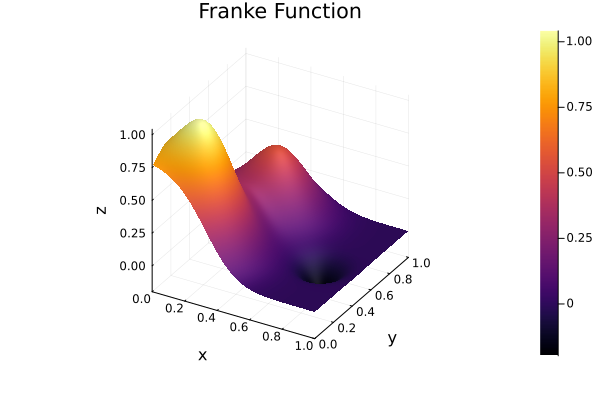

In [27]:
n = 1000
x = range(0, 1, length=n)
y = range(0, 1, length=n)
z = franke.(x, y')

surface(x, y, z, xlabel="x", ylabel="y", zlabel="z", title="Franke Function")

### Polynomial ordinary least squares regression

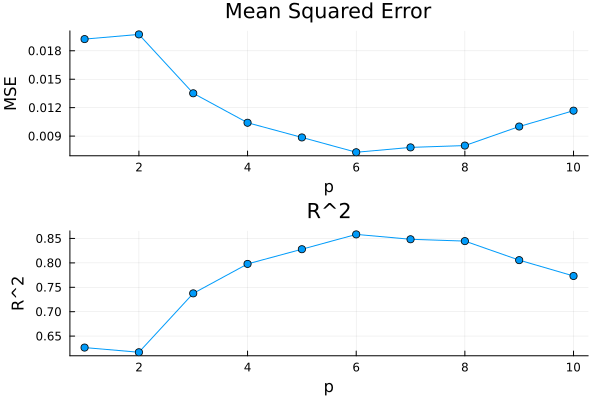

In [49]:
sample_size = 100
train_ratio = 0.8

Random.seed!(0)
x_1 = rand(sample_size)
x_2 = rand(sample_size)
y = franke.(x_1, x_2)

x = hcat(x_1, x_2)
x_scaled = scale_data(x)

x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, train_ratio)

degrees = 10
mse = Vector{Float64}(undef, degrees)
R_squared = Vector{Float64}(undef, degrees)
for p in 1:degrees
  β = polynomial_ordinary_least_squares(x_train, y_train, p)
  X_test = polynomial_design_matrix(x_test, p)
  y_pred = X_test * β
  mse[p] = mean((y_test - y_pred).^2)
  R_squared[p] = r_squared(y_test, y_pred)
end

layout = @layout [a ; b]

p1 = plot(
  1:degrees, mse, 
  marker=:circle, 
  label="", 
  title="Mean Squared Error", 
  xlabel="p", 
  ylabel="MSE")
p2 = plot(
  1:degrees, R_squared, 
  marker=:circle, 
  label="", 
  title="R^2", 
  xlabel="p", 
  ylabel="R^2")

plot(p1, p2, layout=layout)